# Sinhala Extrinsic Evaluation — Unicode vs. Romanized Script Figures

**Sinhala Script Robustness Project — Extrinsic Downstream Task Analysis**

This notebook analyzes and visualizes how 10 language models perform on three
downstream tasks — **Sinhala MMLU**, **SOLD** (offensive-language detection),
and **Global PIQA** — when the input is presented in native Sinhala Unicode
versus Romanized Sinhala (Singlish). It goes beyond plain accuracy into the
*mechanics* of script sensitivity: tokenizer cost, per-example answer
concordance (with McNemar's test), classification quality under class
imbalance, subject/difficulty hotspots, and cultural-specificity effects.

**Input:** `all_models_extrinsic_summary.csv` plus five deeper aggregate CSVs (MMLU domain/difficulty breakdown, tokenizer-efficiency, paired concordance/McNemar's test, SOLD confusion metrics, PIQA cultural-specificity breakdown) — see `src/analysis/aggregate_extrinsic_summary.py` and `src/analysis/aggregate_extrinsic_rich.py`.

**Output:** publication-ready figures (300 DPI PNG + vector PDF) in `output/figures/`

| Task | N | What it measures |
|---|---|---|
| Sinhala MMLU | 6,879 | Multiple-choice knowledge/reasoning in Sinhala |
| SOLD | 2,500 | Offensive-language detection (binary, class-imbalanced ~59/41) |
| Global PIQA | 100 | Physical commonsense reasoning (translated) |

> **Caveat carried through this analysis:** Global PIQA's *N* = 100 is far
> smaller than the other two tasks, so its accuracy estimates — and
> especially the cultural-specificity subgroup split in Section 11 — carry
> proportionally more sampling noise. Weighted cautiously relative to
> MMLU/SOLD in any headline claim.

**Contents:** 0. Setup &middot; 1. Data audit &middot; 2. Benchmark breakdown &middot;
3. Script-gap heatmap &middot; 4. Parity scatter &middot; 5. Radar / parallel coordinates &middot;
6. Instruction-tuning classification &middot; **7. Tokenizer efficiency** &middot;
**8. MMLU domain &times; difficulty hotspots** &middot; **9. Paired concordance &
McNemar's test** &middot; **10. SOLD classification quality** &middot;
**11. PIQA cultural specificity** &middot; 12. Executive summary


## 0. Setup — Imports, Publication Style, Config

In [1]:

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# ============================================================
# Paths
# ============================================================
DATA_PATHS = {
    "all_models_extrinsic_summary.csv": Path("all_models_extrinsic_summary.csv"),
    "all_models_mmlu_domain_difficulty.csv": Path("all_models_mmlu_domain_difficulty.csv"),
    "all_models_token_efficiency.csv": Path("all_models_token_efficiency.csv"),
    "all_models_concordance.csv": Path("all_models_concordance.csv"),
    "all_models_sold_confusion.csv": Path("all_models_sold_confusion.csv"),
    "all_models_piqa_cultural.csv": Path("all_models_piqa_cultural.csv"),
}

FIG_DIR = Path("output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Publication style (ACL/EMNLP-style: serif type, high contrast,
# clean gridlines, colorblind-safe palette)
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Georgia", "Times New Roman", "serif"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})
sns.set_style("whitegrid", {"axes.edgecolor": "#333333"})

PALETTE = sns.color_palette("colorblind")
COLOR_UNICODE = PALETTE[0]      # blue
COLOR_ROMANIZED = PALETTE[1]    # orange
COLOR_POSITIVE = PALETTE[3]     # red-ish (Unicode-favoring / degradation)
COLOR_NEGATIVE = PALETTE[0]     # blue (Romanized-favoring)
DIVERGING_CMAP = "RdBu_r"       # colorblind-safe diverging (ColorBrewer)

BENCHMARKS = ["Sinhala MMLU", "SOLD", "Global PIQA"]
BENCHMARK_N = {"Sinhala MMLU": 6879, "SOLD": 2500, "Global PIQA": 100}


def uni_col(b):
    return f"{b} Unicode Acc (%)"


def rom_col(b):
    return f"{b} Romanized Acc (%)"


def delta_col(b):
    return f"{b} Delta (pp)"


def save_fig(fig, name):
    """Save a figure as both 300 DPI PNG and vector PDF under output/figures/."""
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path.name} and {pdf_path.name}")


print("Setup complete.")


Setup complete.


## 1. Data Parsing & Sanity Audit

In [2]:

df = pd.read_csv(DATA_PATHS["all_models_extrinsic_summary.csv"])

# ---- Deltas (Unicode - Romanized) per benchmark, in percentage points ----
for b in BENCHMARKS:
    df[delta_col(b)] = df[uni_col(b)] - df[rom_col(b)]

# ---- Macro-average accuracy across the three benchmarks ----
df["Macro Avg Unicode Acc (%)"] = df[[uni_col(b) for b in BENCHMARKS]].mean(axis=1)
df["Macro Avg Romanized Acc (%)"] = df[[rom_col(b) for b in BENCHMARKS]].mean(axis=1)
df["Macro Avg Delta (pp)"] = df["Macro Avg Unicode Acc (%)"] - df["Macro Avg Romanized Acc (%)"]

df = df.sort_values("Macro Avg Unicode Acc (%)", ascending=False).reset_index(drop=True)
MODEL_ORDER = df["Model"].tolist()  # canonical ordering reused across every figure below

# ---- Sanity audit ----
acc_cols = [uni_col(b) for b in BENCHMARKS] + [rom_col(b) for b in BENCHMARKS]
n_models = len(df)
n_missing = df[acc_cols].isna().sum().sum()
out_of_range = ((df[acc_cols] < 0) | (df[acc_cols] > 100)).sum().sum()
n_duplicate_models = df["Model"].duplicated().sum()

print("=" * 70)
print("SANITY AUDIT")
print("=" * 70)
print(f"Models loaded:                {n_models}")
print(f"Duplicate model names:        {n_duplicate_models}")
print(f"Missing accuracy values:      {n_missing}")
print(f"Accuracy values out of [0,100]: {out_of_range}")
print(f"Columns: {list(df.columns)}")
assert n_missing == 0, "Found missing accuracy values — investigate before plotting."
assert out_of_range == 0, "Found accuracy values outside [0, 100] — investigate before plotting."
assert n_duplicate_models == 0, "Duplicate model rows found — aggregation script may need re-running."
print("All checks passed.")

display(
    df[["Model", "Macro Avg Unicode Acc (%)", "Macro Avg Romanized Acc (%)", "Macro Avg Delta (pp)"]]
    .round(2)
    .style.background_gradient(subset=["Macro Avg Delta (pp)"], cmap=DIVERGING_CMAP, vmin=-20, vmax=20)
    .format(precision=2)
)


SANITY AUDIT
Models loaded:                10
Duplicate model names:        0
Missing accuracy values:      0
Accuracy values out of [0,100]: 0
Columns: ['Model', 'Sinhala MMLU Unicode Acc (%)', 'Sinhala MMLU Romanized Acc (%)', 'SOLD Unicode Acc (%)', 'SOLD Romanized Acc (%)', 'Global PIQA Unicode Acc (%)', 'Global PIQA Romanized Acc (%)', 'Sinhala MMLU Delta (pp)', 'SOLD Delta (pp)', 'Global PIQA Delta (pp)', 'Macro Avg Unicode Acc (%)', 'Macro Avg Romanized Acc (%)', 'Macro Avg Delta (pp)']
All checks passed.


,Model,Macro Avg Unicode Acc (%),Macro Avg Romanized Acc (%),Macro Avg Delta (pp)
0,Qwen-3.5-9B,53.48,41.89,11.59
1,Qwen-3.5-4B,51.41,43.44,7.97
2,Llama-3.1-8B-Instruct,50.43,44.92,5.51
3,Qwen2-7B-Instruct,45.30,41.92,3.38
4,Hormoz-8B,44.56,44.10,0.46
5,zephyr-7b-beta,44.01,44.88,-0.87
6,stablelm-zephyr-3b,42.49,42.32,0.16
7,SmolLM3-3B,39.69,39.13,0.56
8,TinyLlama-1.1B-Chat-v1.0,21.97,25.73,-3.77
9,LaMini-GPT-1.5B,1.42,28.99,-27.57


In [3]:

best_uni = df.loc[df["Macro Avg Unicode Acc (%)"].idxmax()]
worst_gap = df.loc[df["Macro Avg Delta (pp)"].idxmax()]
best_parity = df.loc[df["Macro Avg Delta (pp)"].abs().idxmin()]
mean_delta = df["Macro Avg Delta (pp)"].mean()

display(Markdown(
    f"**Audit takeaway.** Across the {n_models} models, macro-average Unicode "
    f"accuracy ranges from {df['Macro Avg Unicode Acc (%)'].min():.1f}% to "
    f"{df['Macro Avg Unicode Acc (%)'].max():.1f}%, with **{best_uni['Model']}** "
    "leading on native-script input. The mean script gap (Unicode minus "
    f"Romanized, macro-averaged) across all models is **{mean_delta:+.2f} pp**, "
    "i.e. models are on average "
    f"{'more accurate on Unicode' if mean_delta > 0 else 'more accurate on Romanized'} "
    f"input. **{worst_gap['Model']}** shows the largest Unicode-favoring gap "
    f"({worst_gap['Macro Avg Delta (pp)']:+.2f} pp), while **{best_parity['Model']}** "
    f"is closest to script parity ({best_parity['Macro Avg Delta (pp)']:+.2f} pp)."
))


**Audit takeaway.** Across the 10 models, macro-average Unicode accuracy ranges from 1.4% to 53.5%, with **Qwen-3.5-9B** leading on native-script input. The mean script gap (Unicode minus Romanized, macro-averaged) across all models is **-0.26 pp**, i.e. models are on average more accurate on Romanized input. **Qwen-3.5-9B** shows the largest Unicode-favoring gap (+11.59 pp), while **stablelm-zephyr-3b** is closest to script parity (+0.16 pp).

## 2. Benchmark Performance Breakdown (Grouped Bar Chart)

Saved 01_benchmark_breakdown_grouped_bar.png and 01_benchmark_breakdown_grouped_bar.pdf


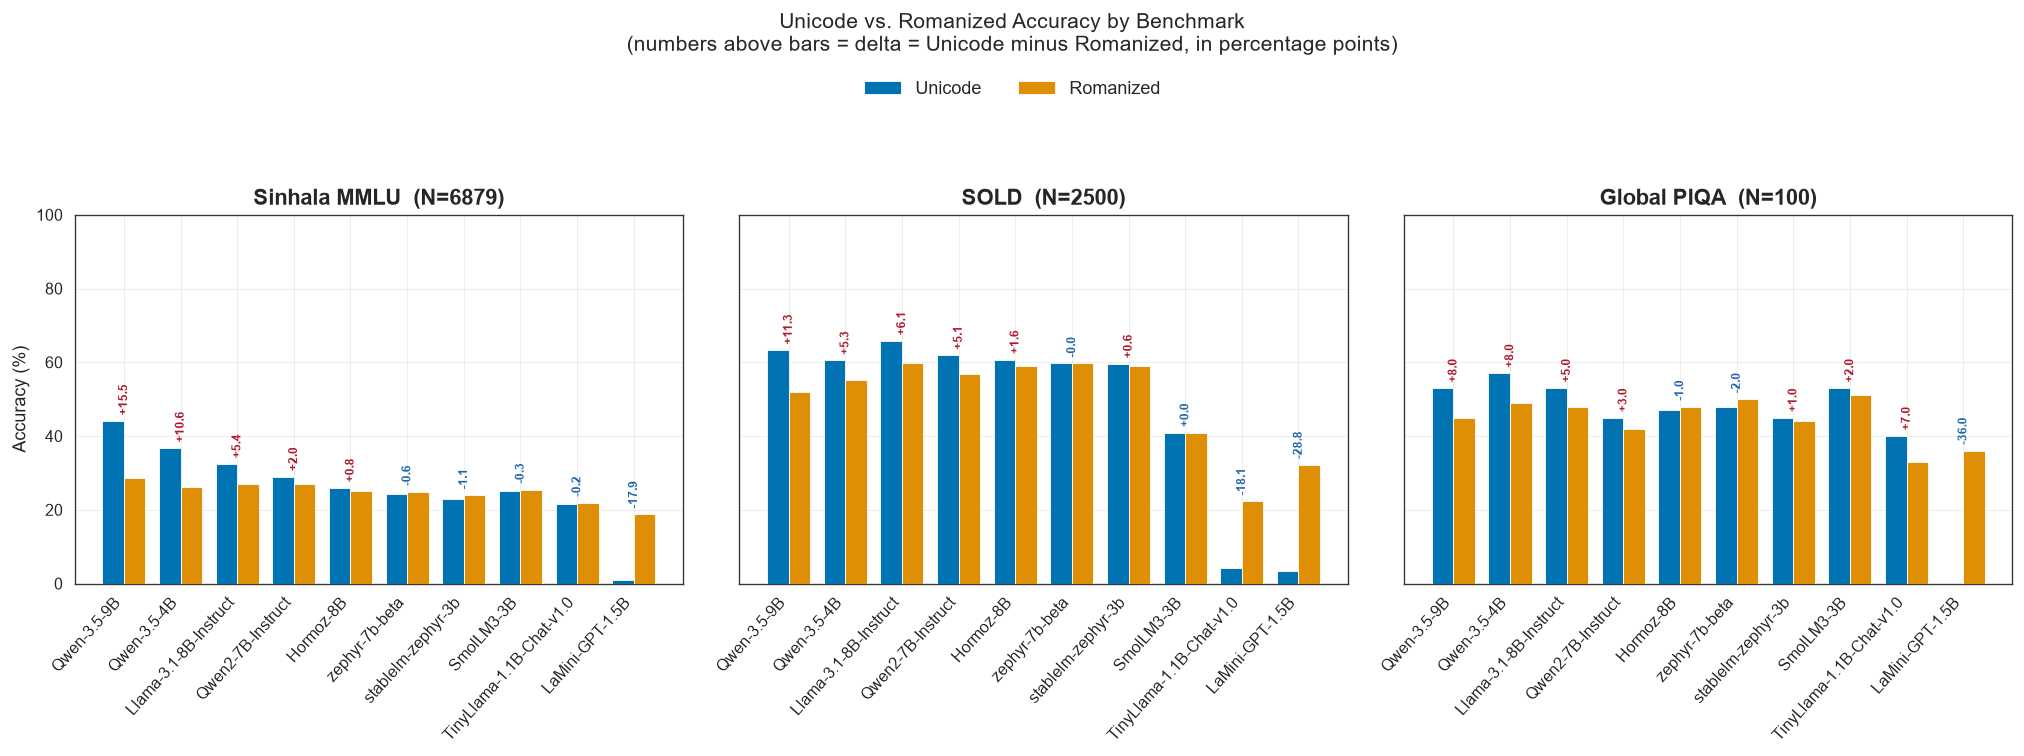

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
x = np.arange(len(MODEL_ORDER))
width = 0.38

for ax, b in zip(axes, BENCHMARKS):
    uni_vals = df.set_index("Model").loc[MODEL_ORDER, uni_col(b)].values
    rom_vals = df.set_index("Model").loc[MODEL_ORDER, rom_col(b)].values
    deltas = uni_vals - rom_vals

    ax.bar(x - width / 2, uni_vals, width, label="Unicode", color=COLOR_UNICODE,
           edgecolor="white", linewidth=0.5, zorder=3)
    ax.bar(x + width / 2, rom_vals, width, label="Romanized", color=COLOR_ROMANIZED,
           edgecolor="white", linewidth=0.5, zorder=3)

    for xi, d in zip(x, deltas):
        top = max(uni_vals[xi], rom_vals[xi])
        color = "#b2182b" if d > 0 else "#2166ac"
        ax.annotate(f"{d:+.1f}", xy=(xi, top + 1.5), ha="center", va="bottom",
                    fontsize=7.3, color=color, fontweight="bold", rotation=90)

    ax.set_title(f"{b}  (N={BENCHMARK_N[b]})")
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=48, ha="right")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.set_axisbelow(True)

axes[0].set_ylabel("Accuracy (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06), fontsize=11)
fig.suptitle("Unicode vs. Romanized Accuracy by Benchmark\n"
             "(numbers above bars = delta = Unicode minus Romanized, in percentage points)",
             y=1.14, fontsize=12.5)
fig.tight_layout()
save_fig(fig, "01_benchmark_breakdown_grouped_bar")
plt.show()


In [5]:

per_task_mean_delta = {b: df[delta_col(b)].mean() for b in BENCHMARKS}
hardest_task = max(per_task_mean_delta, key=per_task_mean_delta.get)
easiest_task = min(per_task_mean_delta, key=per_task_mean_delta.get)
gap_summary = "; ".join(f"{b}: {per_task_mean_delta[b]:+.2f} pp" for b in BENCHMARKS)

display(Markdown(
    f"**Insight.** Mean script gap by task — {gap_summary}. "
    f"**{hardest_task}** shows the largest average Unicode-favoring gap, "
    "suggesting romanization costs models the most on this task, while "
    f"**{easiest_task}** is the most script-robust task on average. "
    "Per-model bars that flip sign (Romanized bar taller than Unicode) "
    "indicate cases where romanization *helps* — plausible when a model's "
    "tokenizer/pretraining corpus under-represents Sinhala Unicode more "
    "severely than transliterated Latin text."
))


**Insight.** Mean script gap by task — Sinhala MMLU: +1.42 pp; SOLD: -1.69 pp; Global PIQA: -0.50 pp. **Sinhala MMLU** shows the largest average Unicode-favoring gap, suggesting romanization costs models the most on this task, while **SOLD** is the most script-robust task on average. Per-model bars that flip sign (Romanized bar taller than Unicode) indicate cases where romanization *helps* — plausible when a model's tokenizer/pretraining corpus under-represents Sinhala Unicode more severely than transliterated Latin text.

## 3. Script Gap Heatmap

Saved 02_script_gap_heatmap.png and 02_script_gap_heatmap.pdf


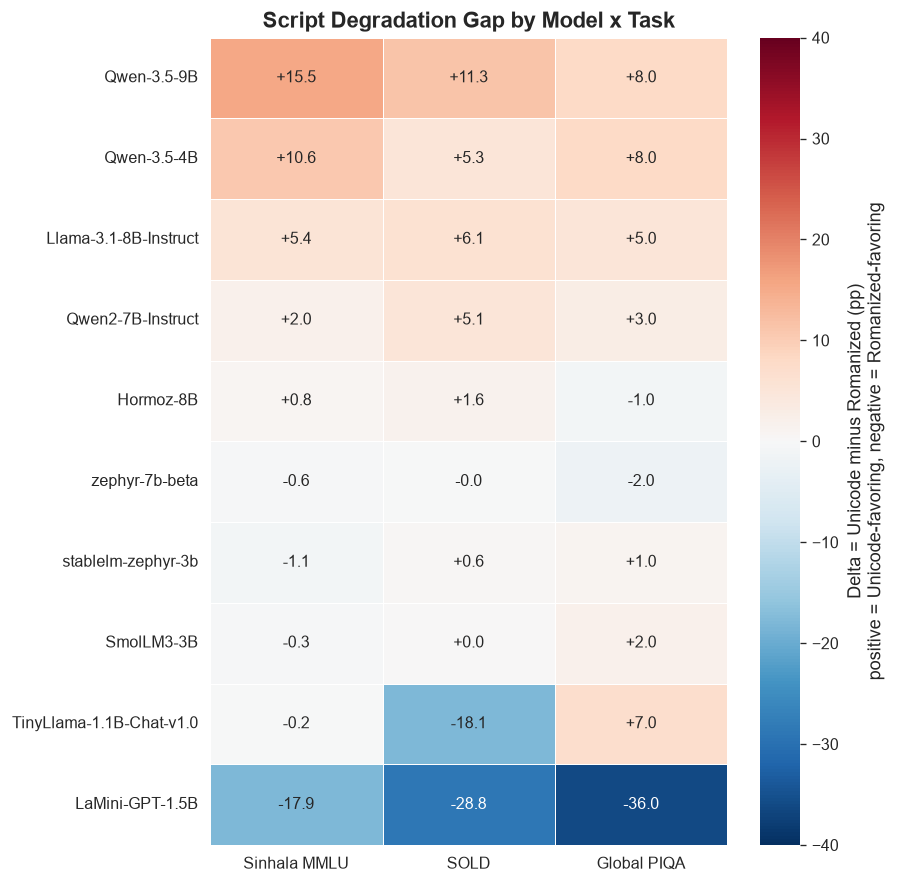

In [6]:

gap_df = df.set_index("Model").loc[MODEL_ORDER, [delta_col(b) for b in BENCHMARKS]]
gap_df.columns = BENCHMARKS

fig, ax = plt.subplots(figsize=(7.5, 7.5))
vmax = np.ceil(gap_df.abs().max().max() / 5) * 5
sns.heatmap(
    gap_df, annot=True, fmt="+.1f", cmap=DIVERGING_CMAP, center=0, vmin=-vmax, vmax=vmax,
    linewidths=0.6, linecolor="white", ax=ax,
    cbar_kws={"label": "Delta = Unicode minus Romanized (pp)\npositive = Unicode-favoring, negative = Romanized-favoring"},
    annot_kws={"fontsize": 9.5},
)
ax.set_title("Script Degradation Gap by Model x Task")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
save_fig(fig, "02_script_gap_heatmap")
plt.show()


In [7]:

unicode_dominant = (gap_df > 0).sum().sum()
romanized_dominant = (gap_df < 0).sum().sum()
total_cells = gap_df.size

display(Markdown(
    f"**Insight.** Of the {total_cells} model x task cells, "
    f"**{unicode_dominant}** favor Unicode input and **{romanized_dominant}** "
    "favor Romanized input. Row patterns (a whole model consistently one "
    "color) point to a *model-level* script sensitivity, whereas column "
    "patterns (a whole task consistently one color) point to a *task-level* "
    "script sensitivity — e.g. short, informal SOLD text may romanize more "
    "predictably than long, formal MMLU questions, or vice versa depending "
    "on each model's pretraining mix."
))


**Insight.** Of the 30 model x task cells, **18** favor Unicode input and **11** favor Romanized input. Row patterns (a whole model consistently one color) point to a *model-level* script sensitivity, whereas column patterns (a whole task consistently one color) point to a *task-level* script sensitivity — e.g. short, informal SOLD text may romanize more predictably than long, formal MMLU questions, or vice versa depending on each model's pretraining mix.

## 4. Script Parity & Degradation Scatter Plot

Saved 03_script_parity_scatter.png and 03_script_parity_scatter.pdf


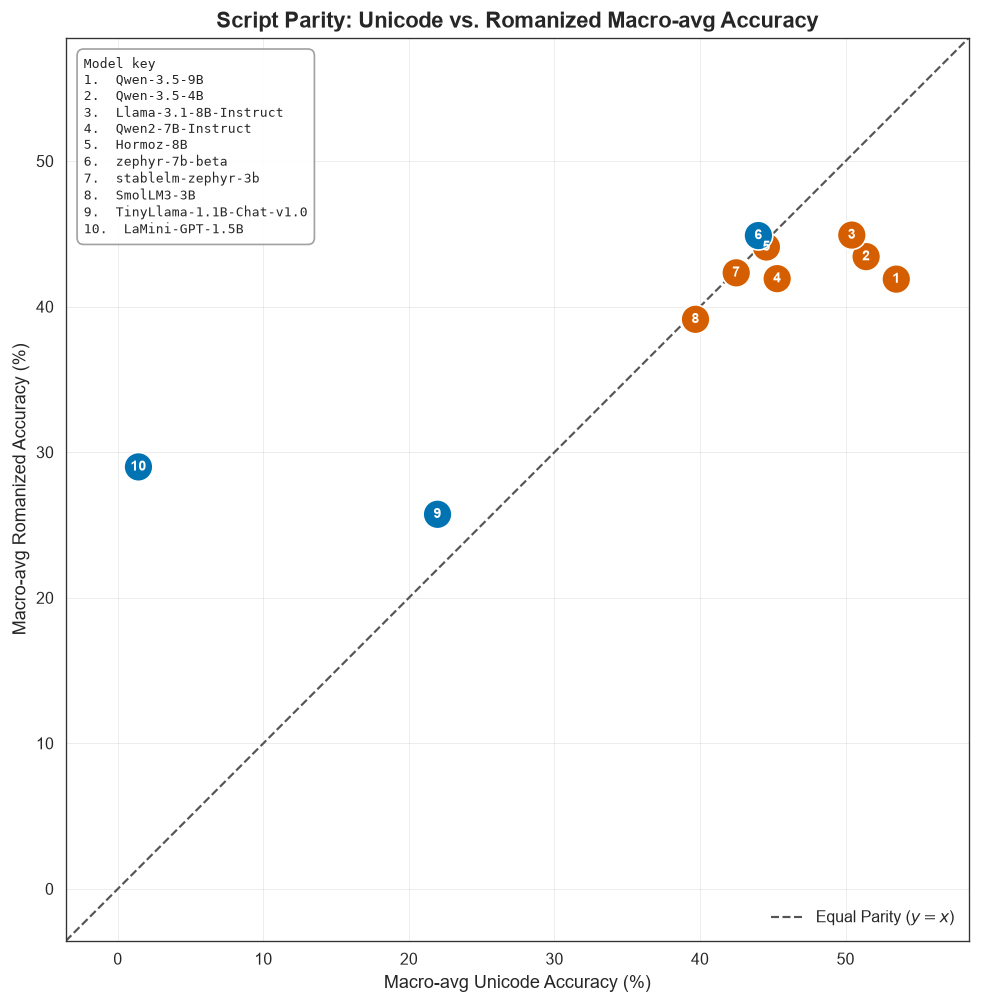

In [8]:

# Numbered markers + a model key, rather than inline text labels: several
# models cluster tightly (macro-avg Unicode ~40-55%), where direct name
# labels collide and become illegible. Index order follows MODEL_ORDER
# (same ranking used in every other figure in this notebook), so "#1" is
# always the top model by macro-avg Unicode accuracy.
fig, ax = plt.subplots(figsize=(8.5, 8.5))

lo = min(df["Macro Avg Unicode Acc (%)"].min(), df["Macro Avg Romanized Acc (%)"].min()) - 5
hi = max(df["Macro Avg Unicode Acc (%)"].max(), df["Macro Avg Romanized Acc (%)"].max()) + 5
ax.plot([lo, hi], [lo, hi], linestyle="--", color="#555555", linewidth=1.3, zorder=1,
        label="Equal Parity ($y = x$)")

model_to_idx = {m: i + 1 for i, m in enumerate(MODEL_ORDER)}
colors = [COLOR_POSITIVE if d > 0 else COLOR_NEGATIVE for d in df["Macro Avg Delta (pp)"]]
ax.scatter(df["Macro Avg Unicode Acc (%)"], df["Macro Avg Romanized Acc (%)"],
           s=300, c=colors, edgecolor="white", linewidth=1.0, zorder=3)
for _, row in df.iterrows():
    ax.annotate(str(model_to_idx[row["Model"]]),
                (row["Macro Avg Unicode Acc (%)"], row["Macro Avg Romanized Acc (%)"]),
                ha="center", va="center", fontsize=8.5, fontweight="bold", color="white", zorder=4)

legend_key = "\n".join(f"{i + 1}.  {m}" for i, m in enumerate(MODEL_ORDER))
ax.text(0.02, 0.98, "Model key\n" + legend_key, transform=ax.transAxes, fontsize=8,
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#999999", alpha=0.92))

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("Macro-avg Unicode Accuracy (%)")
ax.set_ylabel("Macro-avg Romanized Accuracy (%)")
ax.set_title("Script Parity: Unicode vs. Romanized Macro-avg Accuracy")
ax.legend(loc="lower right")
fig.tight_layout()
save_fig(fig, "03_script_parity_scatter")
plt.show()


In [9]:

above_line = (df["Macro Avg Delta (pp)"] < 0).sum()   # Romanized > Unicode -> above y=x
below_line = (df["Macro Avg Delta (pp)"] > 0).sum()   # Unicode > Romanized -> below y=x

display(Markdown(
    f"**Insight.** {below_line} of {n_models} models fall *below* the "
    "equal-parity line (Unicode-dominant — the expected direction if Sinhala "
    f"Unicode is better represented in pretraining data), while {above_line} "
    "fall *above* it (Romanized-dominant). Points far from the diagonal are "
    "the models whose downstream accuracy is most script-sensitive; points "
    "hugging the diagonal are effectively script-invariant for practical "
    "purposes on these tasks."
))


**Insight.** 7 of 10 models fall *below* the equal-parity line (Unicode-dominant — the expected direction if Sinhala Unicode is better represented in pretraining data), while 3 fall *above* it (Romanized-dominant). Points far from the diagonal are the models whose downstream accuracy is most script-sensitive; points hugging the diagonal are effectively script-invariant for practical purposes on these tasks.

## 5. Multi-Task Model Capability Comparison

**Design note.** A radar chart with all 10 models overlaid would produce 10
overlapping, semi-transparent polygons — a well-documented failure mode for
radar charts, which lose legibility beyond roughly 4-5 series due to
occlusion (Highcharts/Inforiver radar-chart guidance; parallel-coordinates
plots scale better to many series). So this section uses **both**, each for
what it's good at:

- A **radar chart** for a focused, high-resolution comparison of the
  **top-4 models by macro-average Unicode accuracy** ("top-tier") across all
  six Unicode/Romanized x task dimensions.
- A **parallel-coordinates plot** for the **full 10-model comparison**,
  colored by an instruction-tuning/base classification (see table below) so
  the base-vs-instruction-tuned pattern remains visible even with all models
  shown at once.

**Instruction-tuning classification** (derived from public model-card naming
conventions — edit `MODEL_METADATA` below if any of these are wrong for your
checkpoints):


In [10]:

# Classification rationale:
#  - "-Instruct" / "-Chat" / "zephyr" (Zephyr = DPO/SFT-tuned) suffixes -> Instruction-tuned
#  - "Qwen-3.5-{4,9}B" here (no "-Base" suffix) -> Instruction-tuned, per this repo's own
#    convention of labeling base checkpoints separately (see results/Intrinsic_evaluation
#    "...-Base" notebooks)
#  - LaMini-GPT and Hormoz are instruction fine-tuned model families
#  - "SmolLM3-3B" (no "-Instruct" suffix) -> Base, since HuggingFaceTB ships
#    SmolLM3-3B and SmolLM3-3B-Instruct as separate checkpoints
MODEL_METADATA = {
    "Hormoz-8B":                 {"tuning": "Instruction-tuned"},
    "LaMini-GPT-1.5B":           {"tuning": "Instruction-tuned"},
    "Llama-3.1-8B-Instruct":     {"tuning": "Instruction-tuned"},
    "Qwen-3.5-4B":               {"tuning": "Instruction-tuned"},
    "Qwen-3.5-9B":               {"tuning": "Instruction-tuned"},
    "Qwen2-7B-Instruct":         {"tuning": "Instruction-tuned"},
    "SmolLM3-3B":                {"tuning": "Base"},
    "TinyLlama-1.1B-Chat-v1.0":  {"tuning": "Instruction-tuned"},
    "stablelm-zephyr-3b":        {"tuning": "Instruction-tuned"},
    "zephyr-7b-beta":            {"tuning": "Instruction-tuned"},
}
df["Tuning"] = df["Model"].map(lambda m: MODEL_METADATA[m]["tuning"])
display(df[["Model", "Tuning"]].sort_values(["Tuning", "Model"]).reset_index(drop=True))


,Model,Tuning
0,SmolLM3-3B,Base
1,Hormoz-8B,Instruction-tuned
2,LaMini-GPT-1.5B,Instruction-tuned
3,Llama-3.1-8B-Instruct,Instruction-tuned
4,Qwen-3.5-4B,Instruction-tuned
5,Qwen-3.5-9B,Instruction-tuned
6,Qwen2-7B-Instruct,Instruction-tuned
7,TinyLlama-1.1B-Chat-v1.0,Instruction-tuned
8,stablelm-zephyr-3b,Instruction-tuned
9,zephyr-7b-beta,Instruction-tuned


Saved 04a_radar_top4_models.png and 04a_radar_top4_models.pdf


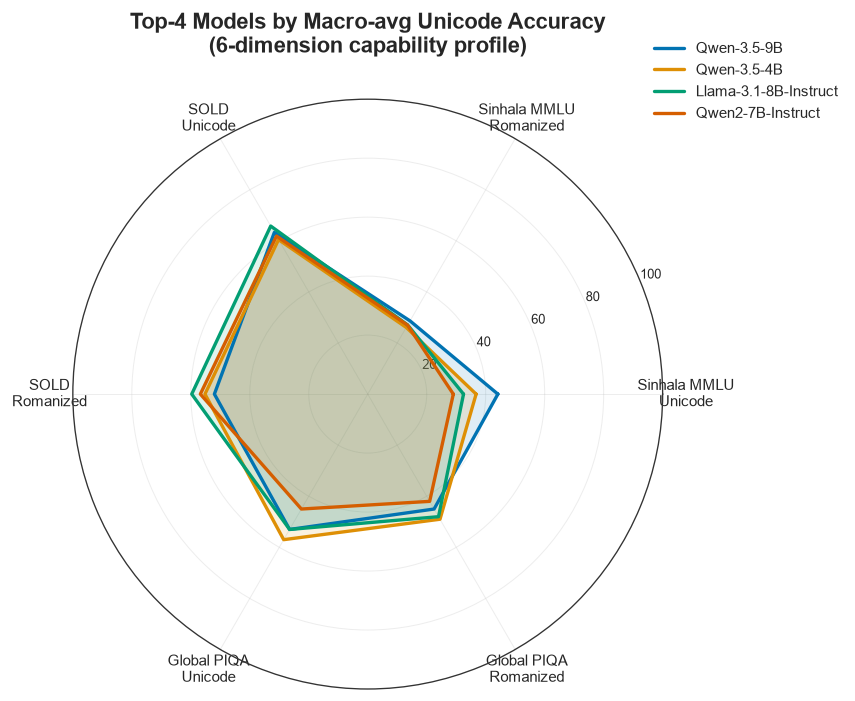

In [11]:

# ---- 5a. Radar chart: top-4 models by macro-avg Unicode accuracy ----
RADAR_AXES = [f"{b}\n{script}" for b in BENCHMARKS for script in ("Unicode", "Romanized")]
radar_cols = [c for b in BENCHMARKS for c in (uni_col(b), rom_col(b))]

top4 = df.nlargest(4, "Macro Avg Unicode Acc (%)")

n_axes = len(RADAR_AXES)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
radar_palette = sns.color_palette("colorblind", n_colors=4)

for (_, row), color in zip(top4.iterrows(), radar_palette):
    values = row[radar_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, color=color, label=row["Model"])
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_AXES, fontsize=8.8)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=7.5)
ax.set_title("Top-4 Models by Macro-avg Unicode Accuracy\n(6-dimension capability profile)", pad=28)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=9)
fig.tight_layout()
save_fig(fig, "04a_radar_top4_models")
plt.show()


Saved 04b_parallel_coordinates_all_models.png and 04b_parallel_coordinates_all_models.pdf


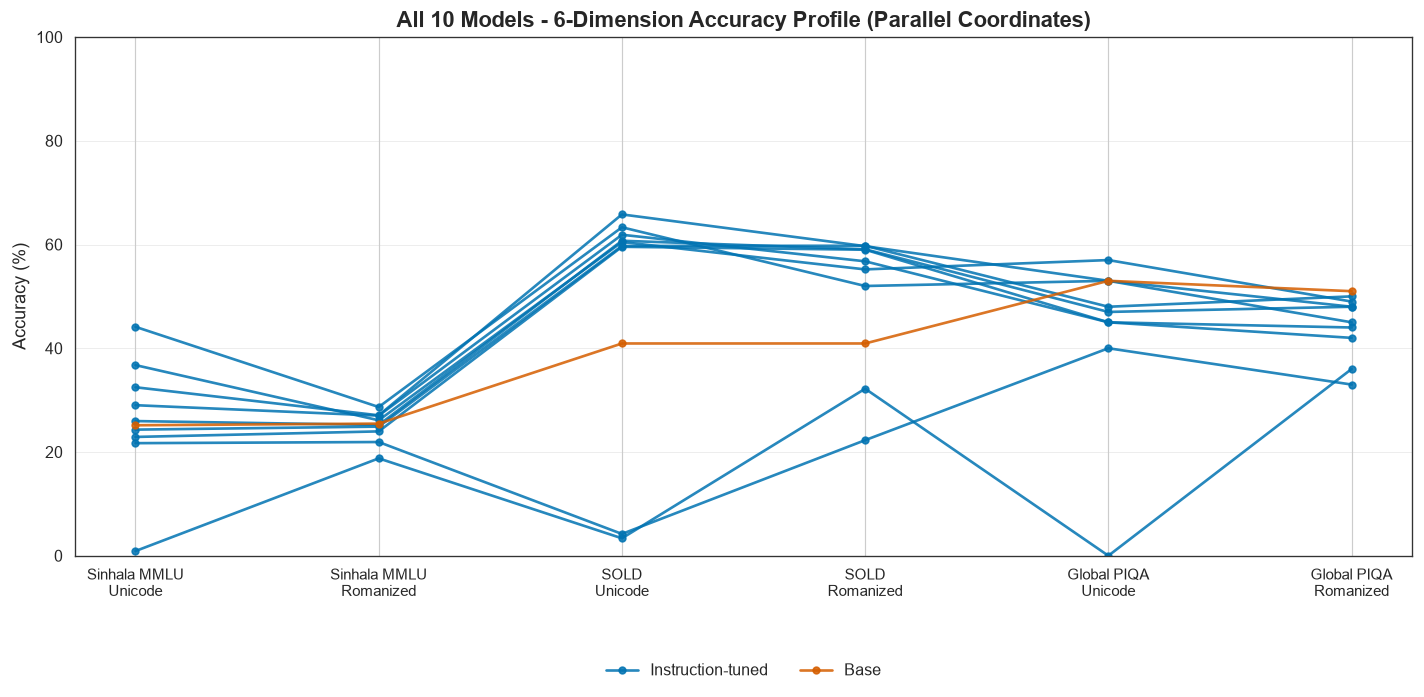

In [12]:

# ---- 5b. Parallel coordinates: all 10 models, colored by tuning ----
pc_cols = radar_cols
pc_df = df[["Model", "Tuning"] + pc_cols].copy()
pc_df.columns = ["Model", "Tuning"] + RADAR_AXES

tuning_colors = {"Instruction-tuned": PALETTE[0], "Base": PALETTE[3]}

fig, ax = plt.subplots(figsize=(12, 6))
x_positions = np.arange(len(RADAR_AXES))

for _, row in pc_df.iterrows():
    ax.plot(x_positions, row[RADAR_AXES].values, marker="o", markersize=4,
            linewidth=1.6, alpha=0.85, color=tuning_colors[row["Tuning"]],
            label=row["Tuning"])

ax.set_xticks(x_positions)
ax.set_xticklabels(RADAR_AXES, fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("All 10 Models - 6-Dimension Accuracy Profile (Parallel Coordinates)")

# de-duplicated legend (one entry per tuning category, not per line)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=2)

for xp in x_positions:
    ax.axvline(xp, color="#cccccc", linewidth=0.7, zorder=0)

fig.tight_layout()
save_fig(fig, "04b_parallel_coordinates_all_models")
plt.show()


In [13]:

n_base = (df["Tuning"] == "Base").sum()
instruct_mean = df.loc[df["Tuning"] == "Instruction-tuned", "Macro Avg Unicode Acc (%)"].mean()
base_mean = df.loc[df["Tuning"] == "Base", "Macro Avg Unicode Acc (%)"].mean()
instruct_delta_mean = df.loc[df["Tuning"] == "Instruction-tuned", "Macro Avg Delta (pp)"].mean()
base_delta_mean = df.loc[df["Tuning"] == "Base", "Macro Avg Delta (pp)"].mean()

display(Markdown(
    f"**Insight.** This model set skews heavily instruction-tuned "
    f"({n_models - n_base} of {n_models} models); only **{n_base}** "
    "checkpoint(s) are base/pretrained-only by this classification, so the "
    "instruct-vs-base comparison here is suggestive rather than "
    "statistically powered. With that caveat: mean macro-avg Unicode "
    f"accuracy is {instruct_mean:.1f}% for instruction-tuned models vs. "
    f"{base_mean:.1f}% for base model(s), and the mean script gap is "
    f"{instruct_delta_mean:+.2f} pp vs. {base_delta_mean:+.2f} pp "
    "respectively. A larger, more balanced base-model sample would be "
    "needed to draw a firm conclusion about whether instruction tuning "
    "itself narrows or widens the Unicode/Romanized gap."
))


**Insight.** This model set skews heavily instruction-tuned (9 of 10 models); only **1** checkpoint(s) are base/pretrained-only by this classification, so the instruct-vs-base comparison here is suggestive rather than statistically powered. With that caveat: mean macro-avg Unicode accuracy is 39.5% for instruction-tuned models vs. 39.7% for base model(s), and the mean script gap is -0.35 pp vs. +0.56 pp respectively. A larger, more balanced base-model sample would be needed to draw a firm conclusion about whether instruction tuning itself narrows or widens the Unicode/Romanized gap.

## 7. Tokenizer Efficiency — the Hidden Cost of Script Choice

Every figure so far measures *accuracy*. This section measures a more
mechanistic quantity: how many tokens each model's tokenizer spends to
represent the *same content* in Sinhala Unicode versus Romanized Sinhala.
This is upstream of accuracy — a model that fragments Sinhala Unicode into
far more tokens than its Romanized equivalent is spending more of its
context budget (and more compute) on the same information, independent of
whether it ultimately answers correctly.


Saved 05_token_inflation_lollipop.png and 05_token_inflation_lollipop.pdf


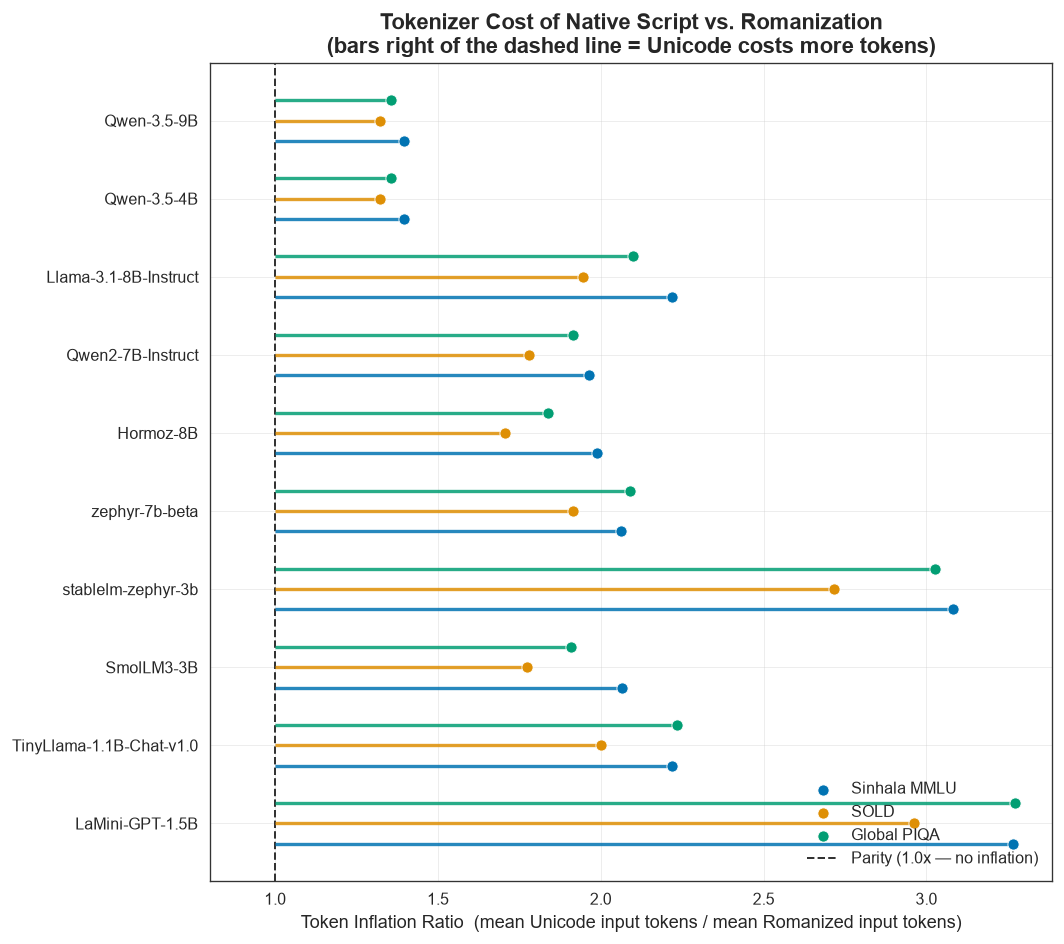

In [14]:

token_eff = pd.read_csv(DATA_PATHS["all_models_token_efficiency.csv"])
token_eff["Model"] = pd.Categorical(token_eff["Model"], categories=MODEL_ORDER, ordered=True)
token_eff = token_eff.sort_values(["Model", "Task"])

fig, ax = plt.subplots(figsize=(9, 8))
n_models_te = len(MODEL_ORDER)
y_base = np.arange(n_models_te)
task_offsets = {"Sinhala MMLU": 0.26, "SOLD": 0.0, "Global PIQA": -0.26}
task_colors = {b: c for b, c in zip(BENCHMARKS, sns.color_palette("colorblind", n_colors=3))}

for task in BENCHMARKS:
    sub = token_eff[token_eff["Task"] == task].set_index("Model").loc[MODEL_ORDER]
    y = y_base + task_offsets[task]
    ax.hlines(y, 1.0, sub["Token Inflation Ratio (Unicode / Romanized)"],
              color=task_colors[task], linewidth=2, alpha=0.85, zorder=2)
    ax.scatter(sub["Token Inflation Ratio (Unicode / Romanized)"], y,
               color=task_colors[task], s=45, label=task, zorder=3, edgecolor="white", linewidth=0.5)

ax.axvline(1.0, color="#333333", linewidth=1.2, linestyle="--", zorder=1,
           label="Parity (1.0x — no inflation)")
ax.set_yticks(y_base)
ax.set_yticklabels(MODEL_ORDER)
ax.invert_yaxis()
ax.set_xlabel("Token Inflation Ratio  (mean Unicode input tokens / mean Romanized input tokens)")
ax.set_title("Tokenizer Cost of Native Script vs. Romanization\n(bars right of the dashed line = Unicode costs more tokens)")
ax.legend(loc="lower right")
ax.set_xlim(left=0.8)
fig.tight_layout()
save_fig(fig, "05_token_inflation_lollipop")
plt.show()


In [15]:

mean_ratio = token_eff["Token Inflation Ratio (Unicode / Romanized)"].mean()
worst_row = token_eff.loc[token_eff["Token Inflation Ratio (Unicode / Romanized)"].idxmax()]
best_row = token_eff.loc[token_eff["Token Inflation Ratio (Unicode / Romanized)"].idxmin()]
pct_above_parity = (token_eff["Token Inflation Ratio (Unicode / Romanized)"] > 1.0).mean() * 100

display(Markdown(
    f"**Insight.** Across all {len(token_eff)} model x task combinations, "
    f"Sinhala Unicode costs a mean of **{mean_ratio:.2f}x** as many input "
    f"tokens as the Romanized equivalent — **{pct_above_parity:.0f}%** of "
    "combinations show Unicode costing *more* tokens, never fewer, by any "
    "meaningful margin. The worst case is "
    f"**{worst_row['Model']}** on **{worst_row['Task']}** at "
    f"**{worst_row['Token Inflation Ratio (Unicode / Romanized)']:.2f}x**; "
    f"the least-inflated is **{best_row['Model']}** on **{best_row['Task']}** "
    f"at **{best_row['Token Inflation Ratio (Unicode / Romanized)']:.2f}x**. "
    "This is strong, mechanistic evidence for the tokenizer-fragmentation "
    "hypothesis floated in earlier sections: these tokenizers were built on "
    "corpora that under-represent Sinhala Unicode, so they fall back to "
    "byte/character-level fragmentation for it — a cost that compounds "
    "directly into context-window and compute budget, on top of any "
    "accuracy effect."
))


**Insight.** Across all 30 model x task combinations, Sinhala Unicode costs a mean of **2.07x** as many input tokens as the Romanized equivalent — **100%** of combinations show Unicode costing *more* tokens, never fewer, by any meaningful margin. The worst case is **LaMini-GPT-1.5B** on **Global PIQA** at **3.27x**; the least-inflated is **Qwen-3.5-9B** on **SOLD** at **1.32x**. This is strong, mechanistic evidence for the tokenizer-fragmentation hypothesis floated in earlier sections: these tokenizers were built on corpora that under-represent Sinhala Unicode, so they fall back to byte/character-level fragmentation for it — a cost that compounds directly into context-window and compute budget, on top of any accuracy effect.

## 8. Sinhala MMLU: Where Does Romanization Hurt Most? (Domain x Difficulty)

Saved 06_mmlu_domain_difficulty_heatmap.png and 06_mmlu_domain_difficulty_heatmap.pdf


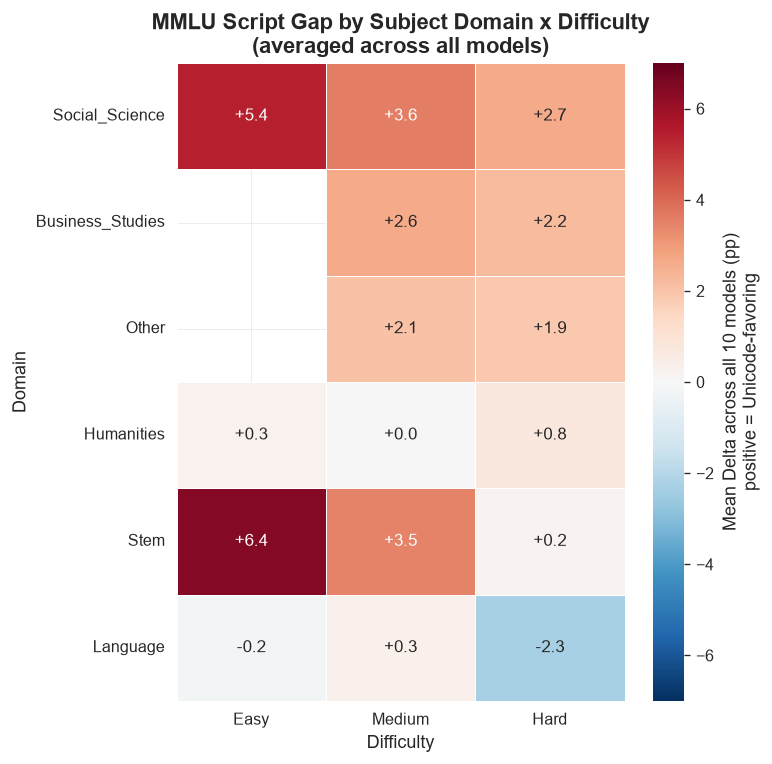

Item counts per cell (summed across all models):


Difficulty,Easy,Medium,Hard
Domain,,,
Social_Science,3700.0,4080.0,2810.0
Business_Studies,NaN,2310.0,2320.0
Other,NaN,5100.0,5040.0
Humanities,11620.0,11280.0,10510.0
Stem,1640.0,1090.0,3410.0
Language,1550.0,1170.0,1160.0


In [16]:

mmlu_dd = pd.read_csv(DATA_PATHS["all_models_mmlu_domain_difficulty.csv"])
DIFFICULTY_ORDER = ["Easy", "Medium", "Hard"]

# Macro-average delta across all 10 models, per domain x difficulty cell —
# where does script sensitivity concentrate, independent of any one model?
pivot = (
    mmlu_dd.groupby(["Domain", "Difficulty"], observed=True)["Delta (pp)"]
    .mean()
    .unstack("Difficulty")
    .reindex(columns=DIFFICULTY_ORDER)
    .sort_values("Hard", ascending=False)
)
n_pivot = (
    mmlu_dd.groupby(["Domain", "Difficulty"], observed=True)["N"]
    .sum()
    .unstack("Difficulty")
    .reindex(columns=DIFFICULTY_ORDER)
    .loc[pivot.index]
)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
vmax = np.ceil(pivot.abs().max().max())
sns.heatmap(pivot, annot=True, fmt="+.1f", cmap=DIVERGING_CMAP, center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "Mean Delta across all 10 models (pp)\npositive = Unicode-favoring"},
            annot_kws={"fontsize": 10})
ax.set_title("MMLU Script Gap by Subject Domain x Difficulty\n(averaged across all models)")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Domain")
fig.tight_layout()
save_fig(fig, "06_mmlu_domain_difficulty_heatmap")
plt.show()

print("Item counts per cell (summed across all models):")
display(n_pivot)


In [17]:

hottest_domain, hottest_diff = pivot.stack().idxmax()
hottest_val = pivot.stack().max()
coolest_domain, coolest_diff = pivot.stack().idxmin()
coolest_val = pivot.stack().min()
domain_means = mmlu_dd.groupby("Domain", observed=True)["Delta (pp)"].mean().sort_values(ascending=False)
difficulty_means = mmlu_dd.groupby("Difficulty", observed=True)["Delta (pp)"].mean().reindex(DIFFICULTY_ORDER)

display(Markdown(
    "**Insight.** The single hardest-hit cell is "
    f"**{hottest_domain} x {hottest_diff}** at **{hottest_val:+.2f} pp** "
    f"mean delta; the most script-robust is **{coolest_domain} x "
    f"{coolest_diff}** at **{coolest_val:+.2f} pp**. By domain alone, "
    f"**{domain_means.index[0]}** has the largest average gap "
    f"({domain_means.iloc[0]:+.2f} pp) and **{domain_means.index[-1]}** the "
    f"smallest ({domain_means.iloc[-1]:+.2f} pp). By difficulty: Easy "
    f"{difficulty_means['Easy']:+.2f} pp, Medium {difficulty_means['Medium']:+.2f} pp, "
    f"Hard {difficulty_means['Hard']:+.2f} pp — "
    f"{'harder questions show a larger script gap, suggesting romanization compounds with reasoning load' if difficulty_means['Hard'] > difficulty_means['Easy'] else 'difficulty does not clearly compound the script gap in this data'}."
))


**Insight.** The single hardest-hit cell is **Stem x Easy** at **+6.40 pp** mean delta; the most script-robust is **Language x Hard** at **-2.33 pp**. By domain alone, **Social_Science** has the largest average gap (+3.89 pp) and **Language** the smallest (-0.73 pp). By difficulty: Easy +2.99 pp, Medium +2.02 pp, Hard +0.90 pp — difficulty does not clearly compound the script gap in this data.

## 9. Paired Concordance & Statistical Significance (McNemar's Test)

Aggregate accuracy deltas can hide the real story: two scripts could produce
*identical* accuracy while the model gets completely *different* individual
items right. This section looks at paired, per-example outcomes — for each
item, was the model correct under Unicode, Romanized, both, or neither? —
and runs **McNemar's test** on the discordant pairs (Unicode-only-correct vs.
Romanized-only-correct) to check whether the flips are a real, statistically
significant script effect rather than noise (asymptotic chi-square test
without continuity correction when discordant pairs ≥ 25, exact binomial
otherwise, per Fagerland et al.'s recommendation for matched-pairs data).


Saved 07_concordance_stacked_bar.png and 07_concordance_stacked_bar.pdf


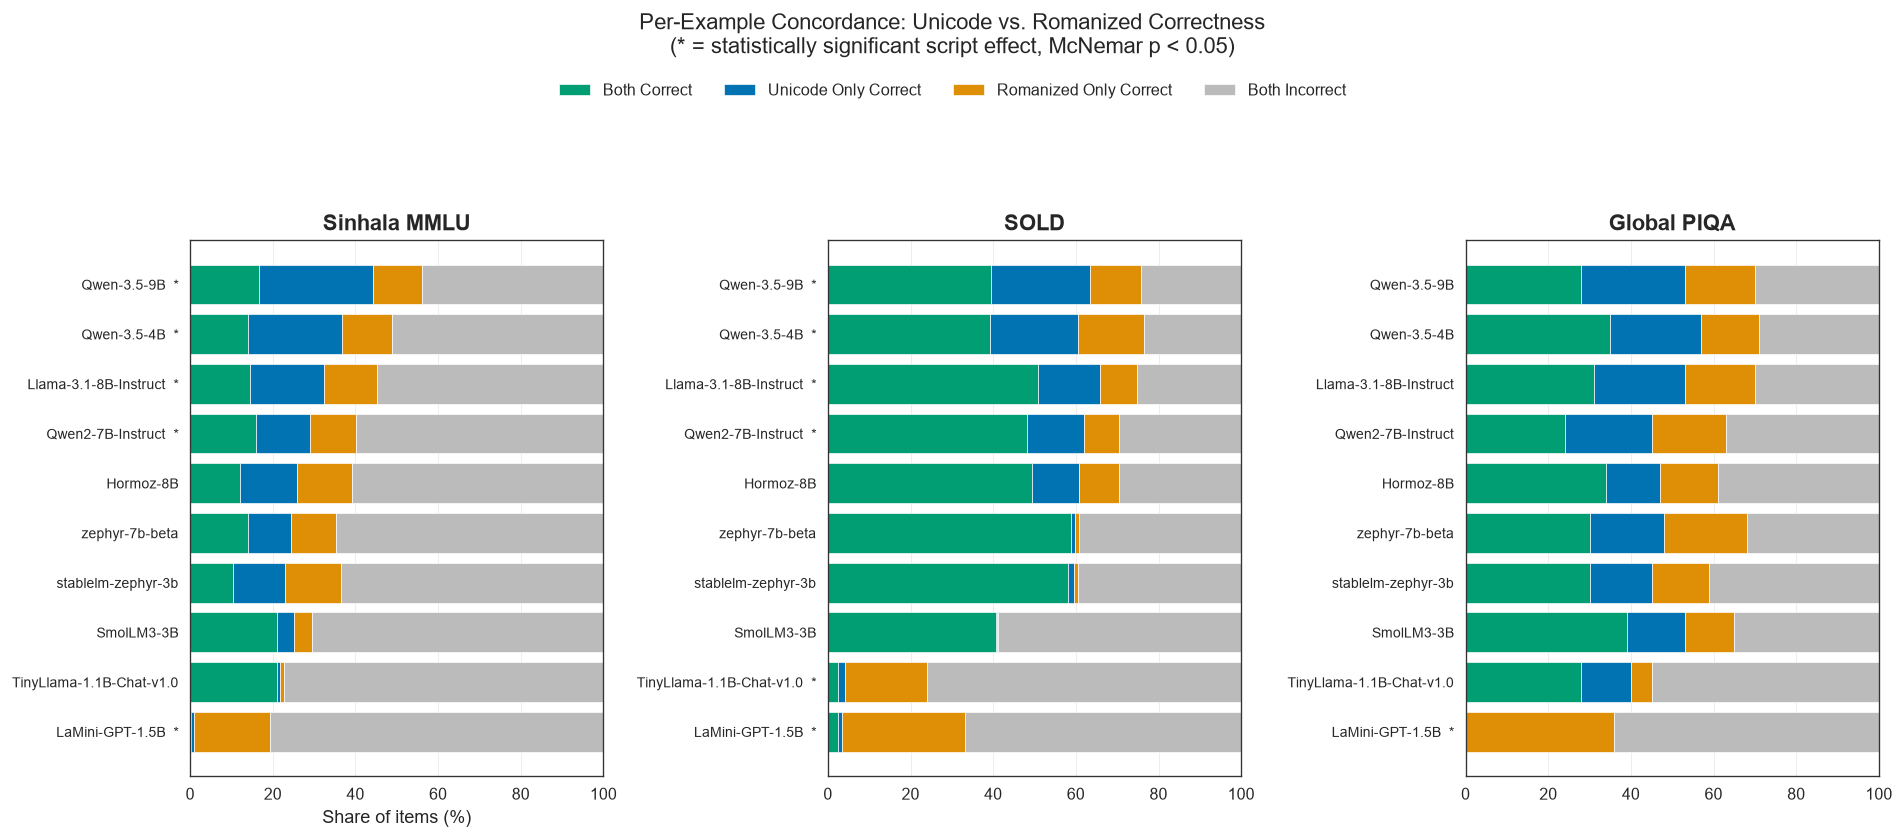

In [18]:

concordance = pd.read_csv(DATA_PATHS["all_models_concordance.csv"])

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True)
seg_colors = [PALETTE[2], PALETTE[0], PALETTE[1], "#bbbbbb"]  # both-correct, uni-only, rom-only, both-wrong
seg_labels = ["Both Correct", "Unicode Only Correct", "Romanized Only Correct", "Both Incorrect"]

for ax, task in zip(axes, BENCHMARKS):
    sub = concordance[concordance["Task"] == task].set_index("Model").loc[MODEL_ORDER]
    props = sub[["Both Correct", "Unicode Only Correct", "Romanized Only Correct", "Both Incorrect"]].div(sub["N"], axis=0) * 100
    left = np.zeros(len(sub))
    y = np.arange(len(sub))
    for seg, color in zip(props.columns, seg_colors):
        ax.barh(y, props[seg], left=left, color=color, label=seg, edgecolor="white", linewidth=0.4)
        left += props[seg].values
    sig_labels = [f"{m}  *" if p < 0.05 else m for m, p in zip(sub.index, sub["McNemar p-value"])]
    ax.set_yticks(y)
    ax.set_yticklabels(sig_labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_title(task)
    ax.set_xlim(0, 100)

axes[0].set_xlabel("Share of items (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), fontsize=9.5)
fig.suptitle("Per-Example Concordance: Unicode vs. Romanized Correctness\n"
             "(* = statistically significant script effect, McNemar p < 0.05)", y=1.16)
fig.tight_layout()
save_fig(fig, "07_concordance_stacked_bar")
plt.show()


In [19]:

n_significant = (concordance["McNemar p-value"] < 0.05).sum()
n_total_pairs = len(concordance)
sig_by_task = concordance.assign(sig=concordance["McNemar p-value"] < 0.05).groupby("Task")["sig"].sum()

display(Markdown(
    f"**Insight.** **{n_significant} of {n_total_pairs}** model x task "
    "combinations show a statistically significant script effect on "
    "per-example correctness (McNemar p < 0.05) — "
    + ", ".join(f"{t}: {int(c)}/{len(MODEL_ORDER)}" for t, c in sig_by_task.items())
    + ". A model can still land on nearly identical *aggregate* accuracy "
    "for both scripts while significantly reshuffling *which* items it "
    "gets right — the aggregate-accuracy view in Sections 2-4 and this "
    "item-level view are answering genuinely different questions, and a "
    "model that looks script-robust in the former can still be brittle in "
    "the latter."
))


**Insight.** **12 of 30** model x task combinations show a statistically significant script effect on per-example correctness (McNemar p < 0.05) — Global PIQA: 1/10, SOLD: 6/10, Sinhala MMLU: 5/10. A model can still land on nearly identical *aggregate* accuracy for both scripts while significantly reshuffling *which* items it gets right — the aggregate-accuracy view in Sections 2-4 and this item-level view are answering genuinely different questions, and a model that looks script-robust in the former can still be brittle in the latter.

## 10. SOLD Classification Quality — Beyond Accuracy

SOLD's gold labels are class-imbalanced (~59% NOT / 41% OFF), so a model
that always predicts the majority class scores respectably on accuracy while
being useless as an offensive-language detector. Precision/Recall/F1 on the
minority **OFF** class exposes that failure mode; plain accuracy alone does
not.


Saved 08_sold_classification_quality.png and 08_sold_classification_quality.pdf


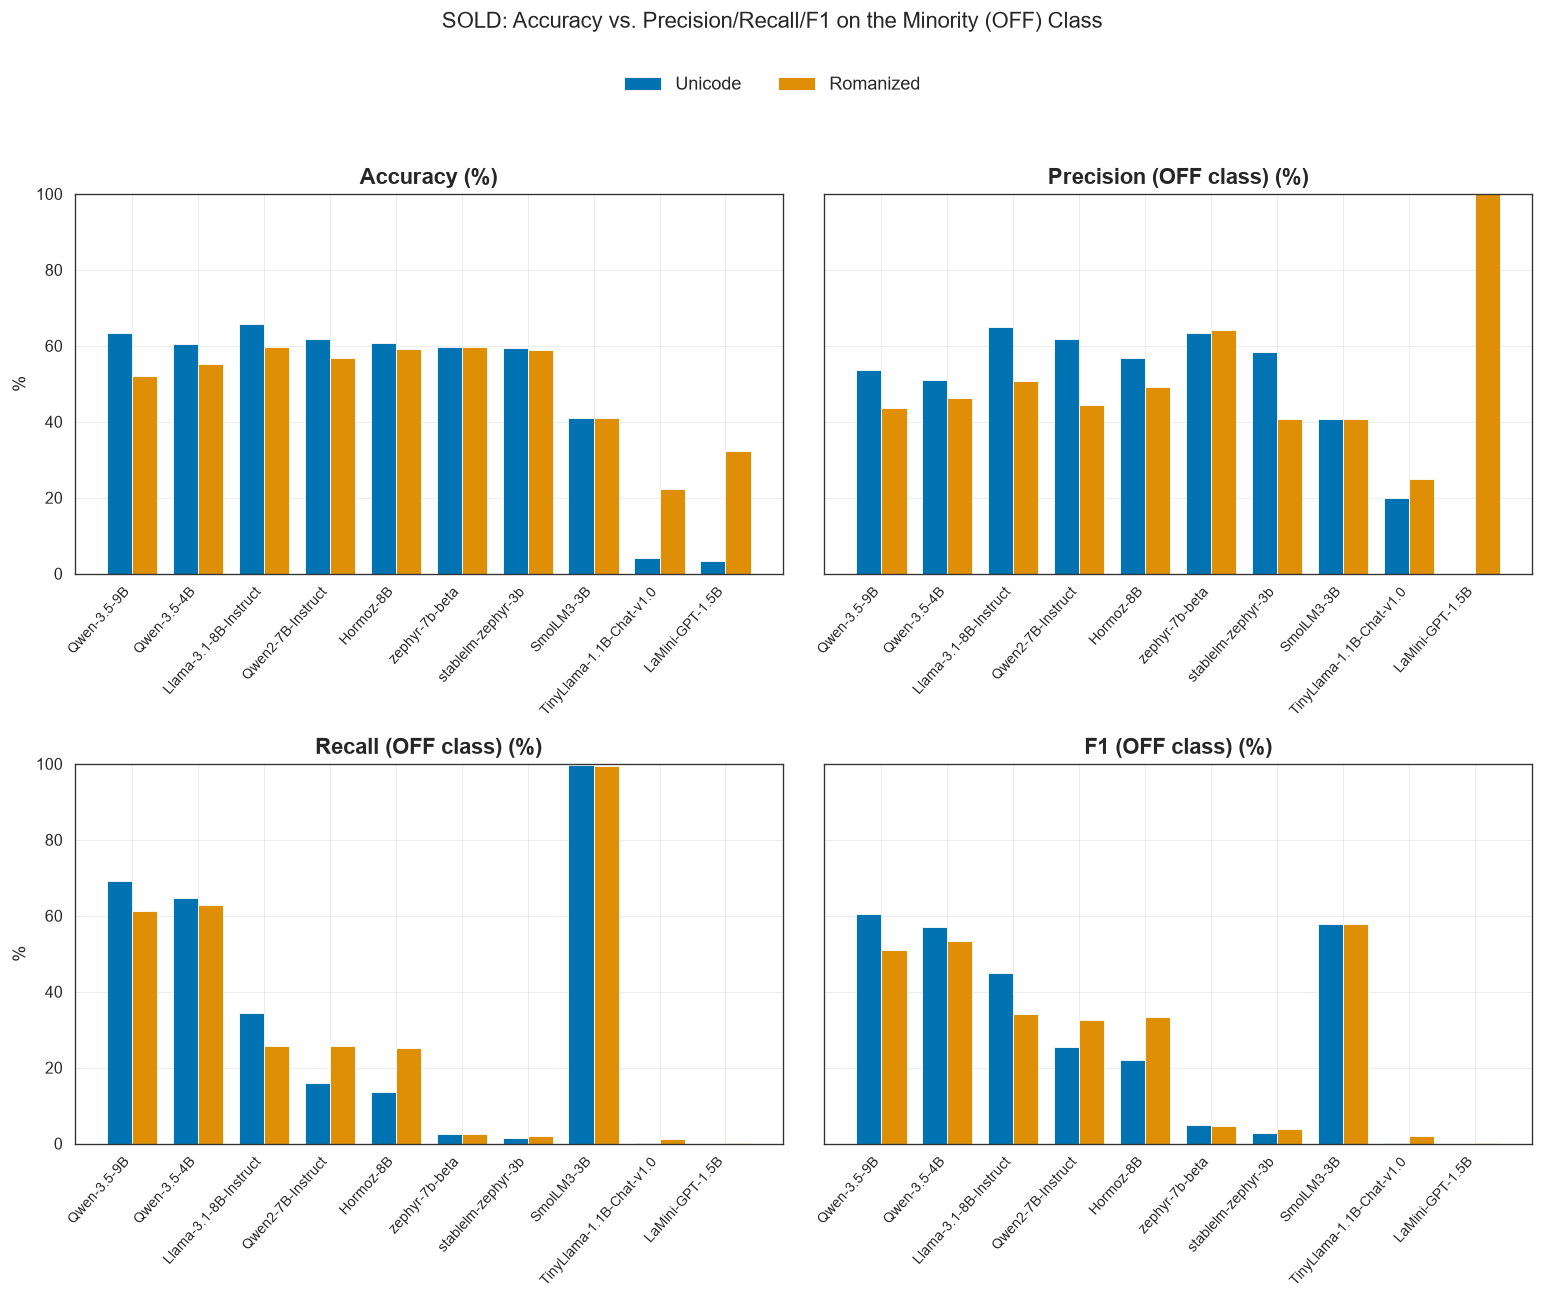

In [20]:

sold_conf = pd.read_csv(DATA_PATHS["all_models_sold_confusion.csv"])
metrics = ["Accuracy (%)", "Precision - OFF class (%)", "Recall - OFF class (%)", "F1 - OFF class (%)"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)
x = np.arange(len(MODEL_ORDER))
width = 0.38

for ax, metric in zip(axes.flat, metrics):
    uni_vals = sold_conf[sold_conf["Script"] == "Unicode"].set_index("Model").loc[MODEL_ORDER, metric].values
    rom_vals = sold_conf[sold_conf["Script"] == "Romanized"].set_index("Model").loc[MODEL_ORDER, metric].values
    ax.bar(x - width / 2, uni_vals, width, label="Unicode", color=COLOR_UNICODE, edgecolor="white", linewidth=0.5)
    ax.bar(x + width / 2, rom_vals, width, label="Romanized", color=COLOR_ROMANIZED, edgecolor="white", linewidth=0.5)
    ax.set_title(metric.replace(" - OFF class", " (OFF class)"))
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=48, ha="right", fontsize=8.5)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)

axes[0, 0].set_ylabel("%")
axes[1, 0].set_ylabel("%")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04), fontsize=11)
fig.suptitle("SOLD: Accuracy vs. Precision/Recall/F1 on the Minority (OFF) Class", y=1.08, fontsize=13)
fig.tight_layout()
save_fig(fig, "08_sold_classification_quality")
plt.show()


In [21]:

degenerate = sold_conf[(sold_conf["Recall - OFF class (%)"] < 5)]
best_f1_row = sold_conf.loc[sold_conf["F1 - OFF class (%)"].idxmax()]

degenerate_summary = (
    "; ".join(f"{r['Model']} ({r['Script']}, recall={r['Recall - OFF class (%)']:.1f}%)"
              for _, r in degenerate.iterrows())
    if len(degenerate) else "none"
)

display(Markdown(
    f"**Insight.** Best OFF-class F1 overall: **{best_f1_row['Model']}** "
    f"({best_f1_row['Script']}, F1={best_f1_row['F1 - OFF class (%)']:.1f}%). "
    f"Near-zero-recall (essentially predicting only 'NOT'): {degenerate_summary}. "
    "A model with high accuracy but near-zero OFF-class recall is not "
    "script-robust in any practically useful sense — it is simply not "
    "performing the task, on either script. This is exactly the kind of "
    "failure mode plain macro-average accuracy (Sections 1-4) cannot surface."
))


**Insight.** Best OFF-class F1 overall: **Qwen-3.5-9B** (Unicode, F1=60.5%). Near-zero-recall (essentially predicting only 'NOT'): LaMini-GPT-1.5B (Unicode, recall=0.0%); LaMini-GPT-1.5B (Romanized, recall=0.1%); stablelm-zephyr-3b (Unicode, recall=1.4%); stablelm-zephyr-3b (Romanized, recall=2.0%); TinyLlama-1.1B-Chat-v1.0 (Unicode, recall=0.1%); TinyLlama-1.1B-Chat-v1.0 (Romanized, recall=1.1%); zephyr-7b-beta (Unicode, recall=2.6%); zephyr-7b-beta (Romanized, recall=2.5%). A model with high accuracy but near-zero OFF-class recall is not script-robust in any practically useful sense — it is simply not performing the task, on either script. This is exactly the kind of failure mode plain macro-average accuracy (Sections 1-4) cannot surface.

## 11. Global PIQA: Does Cultural Specificity Interact with Script Sensitivity?

Global PIQA items are flagged as culturally-specific or universal by the
dataset. This asks whether romanization costs *more* on items that already
require culturally-situated reasoning — a plausible compounding effect. Given
this splits an already-small N=100 into smaller subgroups (~77/23 typical
split), treat this section as a hypothesis-generating exploration, not a
confirmed effect.


Saved 09_piqa_cultural_specificity.png and 09_piqa_cultural_specificity.pdf


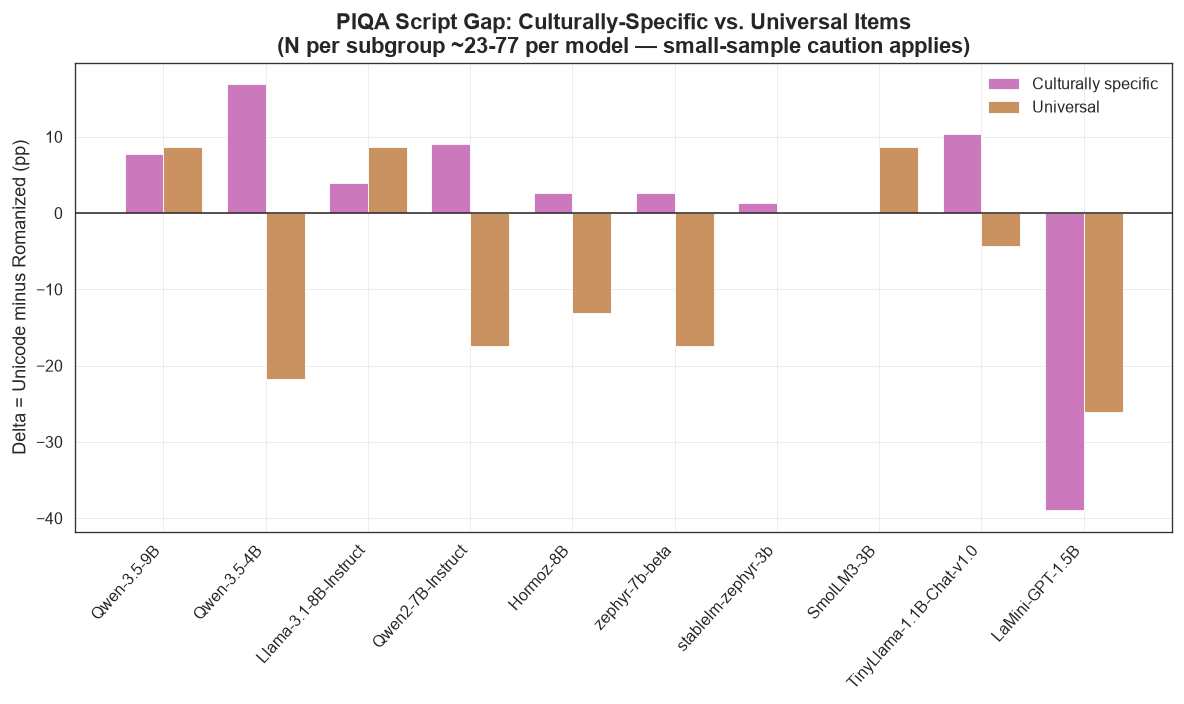

In [22]:

piqa_cult = pd.read_csv(DATA_PATHS["all_models_piqa_cultural.csv"])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(MODEL_ORDER))
width = 0.38
cult_colors = {True: PALETTE[4], False: PALETTE[5]}

for is_cultural, offset in [(True, -width / 2), (False, width / 2)]:
    sub = piqa_cult[piqa_cult["Culturally Specific"] == is_cultural].set_index("Model")
    sub = sub.reindex(MODEL_ORDER)
    ax.bar(x + offset, sub["Delta (pp)"], width,
           label="Culturally specific" if is_cultural else "Universal",
           color=cult_colors[is_cultural], edgecolor="white", linewidth=0.5)

ax.axhline(0, color="#333333", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=48, ha="right")
ax.set_ylabel("Delta = Unicode minus Romanized (pp)")
ax.set_title("PIQA Script Gap: Culturally-Specific vs. Universal Items\n(N per subgroup ~23-77 per model — small-sample caution applies)")
ax.legend()
fig.tight_layout()
save_fig(fig, "09_piqa_cultural_specificity")
plt.show()


In [23]:

cult_mean = piqa_cult.loc[piqa_cult["Culturally Specific"], "Delta (pp)"].mean()
univ_mean = piqa_cult.loc[~piqa_cult["Culturally Specific"], "Delta (pp)"].mean()

display(Markdown(
    f"**Insight.** Mean delta on culturally-specific items: "
    f"**{cult_mean:+.2f} pp** vs. universal items: **{univ_mean:+.2f} pp**. "
    f"{'Culturally-specific items show a larger script penalty on average, consistent with romanization compounding an already-harder reasoning task' if cult_mean > univ_mean else 'This dataset does not show culturally-specific items being more script-sensitive than universal ones'} "
    "— given the small per-subgroup N, treat this as a direction for a "
    "follow-up study with a larger culturally-annotated item set, not a "
    "settled finding."
))


**Insight.** Mean delta on culturally-specific items: **+1.56 pp** vs. universal items: **-7.39 pp**. Culturally-specific items show a larger script penalty on average, consistent with romanization compounding an already-harder reasoning task — given the small per-subgroup N, treat this as a direction for a follow-up study with a larger culturally-annotated item set, not a settled finding.

## 12. Executive Summary & Key Takeaways

In [24]:

n_models_final = len(df)
mean_delta_final = df["Macro Avg Delta (pp)"].mean()
median_delta_final = df["Macro Avg Delta (pp)"].median()
std_delta_final = df["Macro Avg Delta (pp)"].std()
best_model = df.iloc[0]["Model"]
most_robust = df.loc[df["Macro Avg Delta (pp)"].abs().idxmin(), "Model"]
least_robust = df.loc[df["Macro Avg Delta (pp)"].idxmax(), "Model"]
hardest_task_final = max(per_task_mean_delta, key=per_task_mean_delta.get)

summary = (
    "### Executive Summary\n\n"
    f"Across **{n_models_final} models** evaluated on Sinhala MMLU, SOLD, and "
    "Global PIQA under matched Unicode / Romanized conditions:\n\n"
    "1. **Script sensitivity is real but uneven.** The mean macro-avg script "
    f"gap is **{mean_delta_final:+.2f} pp** (median {median_delta_final:+.2f} pp, "
    f"std {std_delta_final:.2f} pp). **{most_robust}** is the most "
    f"script-invariant model by this aggregate measure; **{least_robust}** "
    "shows the sharpest Unicode-favoring degradation.\n\n"
    "2. **The tokenizer, not just the model, pays a script tax.** "
    f"Sinhala Unicode costs a mean of **{mean_ratio:.2f}x** as many input "
    "tokens as Romanized input across every model and task tested "
    "(Section 7) — a purely mechanistic cost, upstream of and independent "
    "from any accuracy effect, and strong evidence that these tokenizers "
    "were trained on corpora that under-represent Sinhala Unicode.\n\n"
    "3. **Aggregate accuracy hides real item-level brittleness.** "
    f"**{n_significant} of {n_total_pairs}** model x task pairs show a "
    "statistically significant McNemar effect (Section 9) — a model can "
    "match its own Unicode accuracy on Romanized input while still "
    "flipping its answer on a significant share of individual items.\n\n"
    f"4. **Task and subject matter interact with script.** **{hardest_task_final}** "
    "carries the largest average script gap of the three tasks; within "
    f"MMLU, **{hottest_domain} x {hottest_diff}** is the single hardest-hit "
    "domain/difficulty cell (Section 8) — script sensitivity is not "
    "uniform across content.\n\n"
    "5. **Accuracy alone can mask a non-functional classifier.** On SOLD, "
    f"{degenerate_summary if degenerate_summary != 'none' else 'none of the models'} "
    "collapse to near-zero recall on the offensive-language class while "
    "still posting a respectable accuracy number (Section 10) — a reminder "
    "to always pair accuracy with class-aware metrics on imbalanced tasks.\n\n"
    "6. **Instruction tuning's effect is inconclusive with this sample.** "
    f"The dataset is dominated by instruction-tuned checkpoints "
    f"({n_models_final - n_base} of {n_models_final}), leaving too small a "
    f"base-model control group ({n_base}) to responsibly claim instruction "
    "tuning narrows or widens the script gap.\n\n"
    f"7. **Overall leaderboard.** **{best_model}** has the highest "
    "macro-average Unicode accuracy of the set — but per (2)-(5) above, the "
    "best *Unicode* model is not automatically the most *script-robust* "
    "one; consult Sections 4, 7, and 9 together before picking a model for "
    "a Romanized-input deployment.\n\n"
    "**Caveat repeated from Section 0:** Global PIQA's N=100 (and its "
    "smaller cultural-specificity subgroups in Section 11) makes those "
    "deltas noisier than MMLU/SOLD; treat single-task PIQA conclusions "
    "cautiously relative to the MMLU/SOLD-driven findings above."
)
display(Markdown(summary))


### Executive Summary

Across **10 models** evaluated on Sinhala MMLU, SOLD, and Global PIQA under matched Unicode / Romanized conditions:

1. **Script sensitivity is real but uneven.** The mean macro-avg script gap is **-0.26 pp** (median +0.51 pp, std 10.62 pp). **stablelm-zephyr-3b** is the most script-invariant model by this aggregate measure; **Qwen-3.5-9B** shows the sharpest Unicode-favoring degradation.

2. **The tokenizer, not just the model, pays a script tax.** Sinhala Unicode costs a mean of **2.07x** as many input tokens as Romanized input across every model and task tested (Section 7) — a purely mechanistic cost, upstream of and independent from any accuracy effect, and strong evidence that these tokenizers were trained on corpora that under-represent Sinhala Unicode.

3. **Aggregate accuracy hides real item-level brittleness.** **12 of 30** model x task pairs show a statistically significant McNemar effect (Section 9) — a model can match its own Unicode accuracy on Romanized input while still flipping its answer on a significant share of individual items.

4. **Task and subject matter interact with script.** **Sinhala MMLU** carries the largest average script gap of the three tasks; within MMLU, **Stem x Easy** is the single hardest-hit domain/difficulty cell (Section 8) — script sensitivity is not uniform across content.

5. **Accuracy alone can mask a non-functional classifier.** On SOLD, LaMini-GPT-1.5B (Unicode, recall=0.0%); LaMini-GPT-1.5B (Romanized, recall=0.1%); stablelm-zephyr-3b (Unicode, recall=1.4%); stablelm-zephyr-3b (Romanized, recall=2.0%); TinyLlama-1.1B-Chat-v1.0 (Unicode, recall=0.1%); TinyLlama-1.1B-Chat-v1.0 (Romanized, recall=1.1%); zephyr-7b-beta (Unicode, recall=2.6%); zephyr-7b-beta (Romanized, recall=2.5%) collapse to near-zero recall on the offensive-language class while still posting a respectable accuracy number (Section 10) — a reminder to always pair accuracy with class-aware metrics on imbalanced tasks.

6. **Instruction tuning's effect is inconclusive with this sample.** The dataset is dominated by instruction-tuned checkpoints (9 of 10), leaving too small a base-model control group (1) to responsibly claim instruction tuning narrows or widens the script gap.

7. **Overall leaderboard.** **Qwen-3.5-9B** has the highest macro-average Unicode accuracy of the set — but per (2)-(5) above, the best *Unicode* model is not automatically the most *script-robust* one; consult Sections 4, 7, and 9 together before picking a model for a Romanized-input deployment.

**Caveat repeated from Section 0:** Global PIQA's N=100 (and its smaller cultural-specificity subgroups in Section 11) makes those deltas noisier than MMLU/SOLD; treat single-task PIQA conclusions cautiously relative to the MMLU/SOLD-driven findings above.

In [25]:

print("Figures written to:", FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob("*")):
    print(" -", f.name)


Figures written to: C:\Users\LENOVO LOQ\Desktop\NLP\sinhala-script-robustness\results\extrinsic_evaluation\output\figures
 - 01_benchmark_breakdown_grouped_bar.pdf
 - 01_benchmark_breakdown_grouped_bar.png
 - 02_script_gap_heatmap.pdf
 - 02_script_gap_heatmap.png
 - 03_script_parity_scatter.pdf
 - 03_script_parity_scatter.png
 - 04a_radar_top4_models.pdf
 - 04a_radar_top4_models.png
 - 04b_parallel_coordinates_all_models.pdf
 - 04b_parallel_coordinates_all_models.png
 - 05_token_inflation_lollipop.pdf
 - 05_token_inflation_lollipop.png
 - 06_mmlu_domain_difficulty_heatmap.pdf
 - 06_mmlu_domain_difficulty_heatmap.png
 - 07_concordance_stacked_bar.pdf
 - 07_concordance_stacked_bar.png
 - 08_sold_classification_quality.pdf
 - 08_sold_classification_quality.png
 - 09_piqa_cultural_specificity.pdf
 - 09_piqa_cultural_specificity.png
